<a href="https://colab.research.google.com/github/ShohanRony/Rangamati-Deforestation/blob/main/Rangamati_Deforestation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RANGAMATI DEFORESTATION MONITORING
Publication-Quality Map Generation — Google Colab
==================================================
Researcher: Shohinur Pervez Shohan, RMSTU
Run each cell in order. All figures saved to Google Drive.
Requires: GEE exports in Drive > Rangamati_Deforestation/
Drive folder: https://drive.google.com/drive/folders/1RDzi_5g9sDM4kHhL7VswFP8gfcBoefrh
"""

In [2]:
#  Install dependencies (run once, restart runtime after)
# ============================================================
!pip install rasterio geopandas matplotlib-scalebar --quiet


In [3]:
#  Mount Google Drive & set paths
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_INPUT  = '/content/drive/MyDrive/Rangamati_Deforestation'
DRIVE_OUTPUT = '/content/drive/MyDrive/Rangamati_Deforestation/Maps'
os.makedirs(DRIVE_OUTPUT, exist_ok=True)

# 2013 excluded — unreliable (insufficient Landsat 8 images, area=868 km²)
FILES = {
    1993: f'{DRIVE_INPUT}/RF_Classified_1993.tif',
    1998: f'{DRIVE_INPUT}/RF_Classified_1998.tif',
    2003: f'{DRIVE_INPUT}/RF_Classified_2003.tif',
    2008: f'{DRIVE_INPUT}/RF_Classified_2008.tif',
    2018: f'{DRIVE_INPUT}/RF_Classified_2018.tif',
    2023: f'{DRIVE_INPUT}/RF_Classified_2023.tif',
}
NDVI_CHANGE = f'{DRIVE_INPUT}/NDVI_Change_1993_2023.tif'
FOREST_1993 = f'{DRIVE_INPUT}/Forest_Mask_1993.tif'
FOREST_2023 = f'{DRIVE_INPUT}/Forest_Mask_2023.tif'

print("Drive mounted. Checking files...")
all_ok = True
for yr, path in FILES.items():
    status = "✓" if os.path.exists(path) else "✗ MISSING"
    if "MISSING" in status:
        all_ok = False
    print(f"  {yr}: {status}  →  {os.path.basename(path)}")

for label, path in [("NDVI Change", NDVI_CHANGE),
                     ("Forest 1993", FOREST_1993),
                     ("Forest 2023", FOREST_2023)]:
    status = "✓" if os.path.exists(path) else "✗ MISSING"
    if "MISSING" in status:
        all_ok = False
    print(f"  {label}: {status}")

print("\n✓ All files found — ready to run!" if all_ok else
      "\n⚠ Some files missing — check Drive folder name")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Checking files...
  1993: ✓  →  RF_Classified_1993.tif
  1998: ✓  →  RF_Classified_1998.tif
  2003: ✓  →  RF_Classified_2003.tif
  2008: ✓  →  RF_Classified_2008.tif
  2018: ✓  →  RF_Classified_2018.tif
  2023: ✓  →  RF_Classified_2023.tif
  NDVI Change: ✓
  Forest 1993: ✓
  Forest 2023: ✓

✓ All files found — ready to run!


In [4]:
# Import libraries & define color scheme
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import rasterio
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

try:
    from matplotlib_scalebar.scalebar import ScaleBar
    HAS_SCALEBAR = True
except ImportError:
    HAS_SCALEBAR = False
    print("scalebar not available — scale bars will be skipped")

# Colorblind-safe, publication-standard palette
CLASS_COLORS = {
    1: '#1a6b1a',   # Dense Forest
    2: '#74b374',   # Degraded Forest / Jhum
    3: '#2166ac',   # Water
    4: '#f4a582',   # Agriculture / Settlement
    5: '#d6c39a',   # Bare Land
}
CLASS_LABELS = {
    1: 'Dense Forest',
    2: 'Degraded Forest / Jhum',
    3: 'Water',
    4: 'Agriculture / Settlement',
    5: 'Bare Land',
}

def make_colormap():
    colors = [CLASS_COLORS[i] for i in range(1, 6)]
    cmap   = mcolors.ListedColormap(colors)
    norm   = mcolors.BoundaryNorm([0.5,1.5,2.5,3.5,4.5,5.5], ncolors=5)
    return cmap, norm

def make_legend_patches():
    return [mpatches.Patch(color=CLASS_COLORS[i], label=CLASS_LABELS[i])
            for i in range(1, 6)]

print("Libraries loaded. Color scheme ready.")

Libraries loaded. Color scheme ready.


In [6]:
# CELL 4 — Helper functions
# ============================================================
def read_raster(path):
    with rasterio.open(path) as src:
        data      = src.read(1).astype(float)
        data[data <= 0] = np.nan
        transform = src.transform
        crs       = src.crs
        bounds    = src.bounds
    return data, transform, crs, bounds

def add_north_arrow(ax, x=0.95, y=0.92, size=0.06):
    ax.annotate('N', xy=(x, y), xytext=(x, y - size),
                xycoords='axes fraction',
                fontsize=10, fontweight='bold', ha='center',
                arrowprops=dict(arrowstyle='->', lw=1.5, color='black'),
                annotation_clip=False)

def add_scale_bar(ax, pixel_size_m=30):
    if HAS_SCALEBAR:
        scalebar = ScaleBar(pixel_size_m, units='m',
                            length_fraction=0.2,
                            location='lower left',
                            color='black', box_alpha=0.7,
                            font_properties={'size': 8})
        ax.add_artist(scalebar)

def add_map_frame(ax, title, fontsize=11):
    ax.set_title(title, fontsize=fontsize, fontweight='bold', pad=6)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

def add_source_text(fig, text):
    fig.text(0.5, 0.01, text, ha='center', fontsize=7,
             color='#555555', style='italic')

print("Helper functions ready.")

Helper functions ready.


In [18]:
!pip install adjustText --quiet

Upazilas found: 10


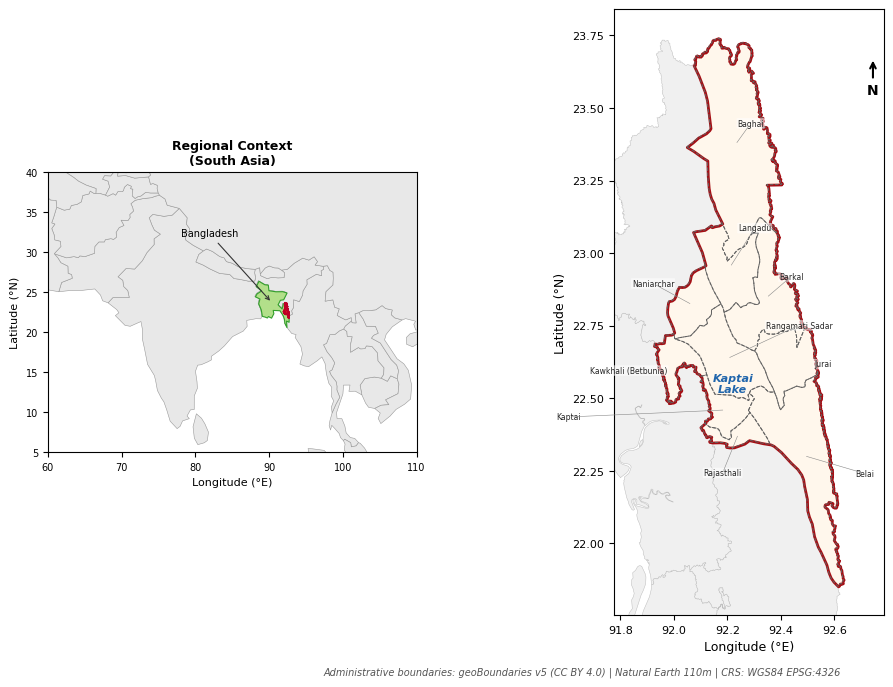

✓ Saved: /content/drive/MyDrive/Rangamati_Deforestation/Maps/Figure1_StudyArea.png


In [21]:
# ============================================================
# CELL 5 — FIGURE 1: Study Area Map
# ============================================================
import urllib.request, os, zipfile
import rasterio
from shapely.geometry import box
from shapely.ops import unary_union

fig, axes = plt.subplots(1, 2, figsize=(12, 7),
                          gridspec_kw={'width_ratios': [1, 2.2]})
fig.patch.set_facecolor('white')

# ── Natural Earth ─────────────────────────────────────────────
_ne_url = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'
_ne_zip = '/tmp/ne_countries.zip'
_ne_dir = '/tmp/ne_countries'
if not os.path.exists(_ne_dir):
    urllib.request.urlretrieve(_ne_url, _ne_zip)
    with zipfile.ZipFile(_ne_zip, 'r') as z: z.extractall(_ne_dir)
world      = gpd.read_file(f'{_ne_dir}/ne_110m_admin_0_countries.shp')
south_asia = world[world['CONTINENT'] == 'Asia']
bangladesh = world[world['NAME'] == 'Bangladesh']

# ── geoBoundaries ADM2 ────────────────────────────────────────
_gb2_path = '/tmp/bgd_adm2.geojson'
if not os.path.exists(_gb2_path):
    urllib.request.urlretrieve(
        'https://github.com/wmgeolab/geoBoundaries/raw/main/'
        'releaseData/gbOpen/BGD/ADM2/geoBoundaries-BGD-ADM2_simplified.geojson',
        _gb2_path)
bgd_adm2  = gpd.read_file(_gb2_path)
rangamati = bgd_adm2[bgd_adm2['shapeName'].str.contains(
    'Rangamati|Parbattya', case=False, na=False)]
if rangamati.empty:
    with rasterio.open(FILES[2023]) as src:
        b = src.bounds
    rangamati = gpd.GeoDataFrame(
        geometry=[box(b.left, b.bottom, b.right, b.top)],
        crs=src.crs).to_crs('EPSG:4326')

# ── geoBoundaries ADM3 ────────────────────────────────────────
_gb3_path = '/tmp/bgd_adm3.geojson'
if not os.path.exists(_gb3_path):
    urllib.request.urlretrieve(
        'https://github.com/wmgeolab/geoBoundaries/raw/main/'
        'releaseData/gbOpen/BGD/ADM3/geoBoundaries-BGD-ADM3_simplified.geojson',
        _gb3_path)
bgd_adm3  = gpd.read_file(_gb3_path)
rangamati_union = rangamati.geometry.union_all()
upazilas = bgd_adm3[bgd_adm3.geometry.centroid.within(rangamati_union)].copy()
print(f"Upazilas found: {len(upazilas)}")

# ── LEFT: Regional context ────────────────────────────────────
ax_left = axes[0]
south_asia.plot(ax=ax_left, color='#e8e8e8', edgecolor='#999999', linewidth=0.4)
bangladesh.plot(ax=ax_left, color='#b2df8a', edgecolor='#33a02c', linewidth=0.8)
rangamati.plot(ax=ax_left, color='#e31a1c', edgecolor='#bd0026', linewidth=1.5)
ax_left.set_xlim(60, 110); ax_left.set_ylim(5, 40)
ax_left.set_xlabel('Longitude (°E)', fontsize=8)
ax_left.set_ylabel('Latitude (°N)', fontsize=8)
ax_left.tick_params(labelsize=7)
ax_left.set_title('Regional Context\n(South Asia)', fontsize=9, fontweight='bold')
ax_left.annotate('Bangladesh', xy=(90.4, 23.7), xytext=(78, 32),
                 fontsize=7, arrowprops=dict(arrowstyle='->', color='#333333', lw=0.8))

# ── RIGHT: Rangamati + upazilas ───────────────────────────────
ax_right = axes[1]
bgd_adm2.plot(ax=ax_right, color='#f0f0f0', edgecolor='#bdbdbd', linewidth=0.35)
rangamati.plot(ax=ax_right, color='#fff7ec', edgecolor='#a50f15', linewidth=2.0)
if not upazilas.empty:
    upazilas.boundary.plot(ax=ax_right, color='#636363',
                            linewidth=0.7, linestyle='--')
    # Smart label placement — avoid overlap using adjustText
    try:
        from adjustText import adjust_text
        texts = []
        for _, row in upazilas.iterrows():
            name = str(row.get('shapeName', ''))
            # Shorten long names for readability
            short = (name.replace(' Chhari', '')
                         .replace(' Sadar', ' Sadar')
                         .strip())
            if name:
                cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
                t = ax_right.text(cx, cy, short, fontsize=5.5,
                                  ha='center', va='center', color='#252525',
                                  bbox=dict(boxstyle='round,pad=0.1',
                                            fc='white', alpha=0.55, ec='none'))
                texts.append(t)
        adjust_text(texts, ax=ax_right,
            expand_text=(1.1, 1.2),
            expand_points=(1.0, 1.0),
            force_text=(0.3, 0.3),      # ←
            arrowprops=dict(arrowstyle='-', color='#888888', lw=0.4))
    except ImportError:
        # adjustText not installed — fallback to manual placement
        for _, row in upazilas.iterrows():
            name = str(row.get('shapeName', ''))
            short = name.replace(' Chhari', '').replace(' Sadar', '\nSadar').strip()
            if name:
                cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
                ax_right.annotate(short, xy=(cx, cy),
                                  fontsize=5.5, ha='center', va='center',
                                  color='#252525',
                                  bbox=dict(boxstyle='round,pad=0.1',
                                            fc='white', alpha=0.55, ec='none'))

ax_right.annotate('Kaptai\nLake', xy=(92.22, 22.52), fontsize=8,
                  color='#2166ac', ha='center', style='italic', fontweight='bold')

# Tight zoom to Rangamati only — remove excess whitespace
_b = rangamati.total_bounds
_padx, _pady = 0.15, 0.10
ax_right.set_xlim(_b[0] - _padx, _b[2] + _padx)
ax_right.set_ylim(_b[1] - _pady, _b[3] + _pady)

ax_right.set_xlabel('Longitude (°E)', fontsize=9)
ax_right.set_ylabel('Latitude (°N)', fontsize=9)
ax_right.tick_params(labelsize=8)
ax_right.set_title('Study Area: Rangamati Hill District\n'
                    '(Chittagong Hill Tracts, Bangladesh)',
                    fontsize=10, fontweight='bold')
add_north_arrow(ax_right, x=0.96, y=0.92)
add_map_frame(ax_right, '')
add_source_text(fig,
    'Administrative boundaries: geoBoundaries v5 (CC BY 4.0) | '
    'Natural Earth 110m | CRS: WGS84 EPSG:4326')

plt.tight_layout(pad=2)
out_path = f'{DRIVE_OUTPUT}/Figure1_StudyArea.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Saved: {out_path}")

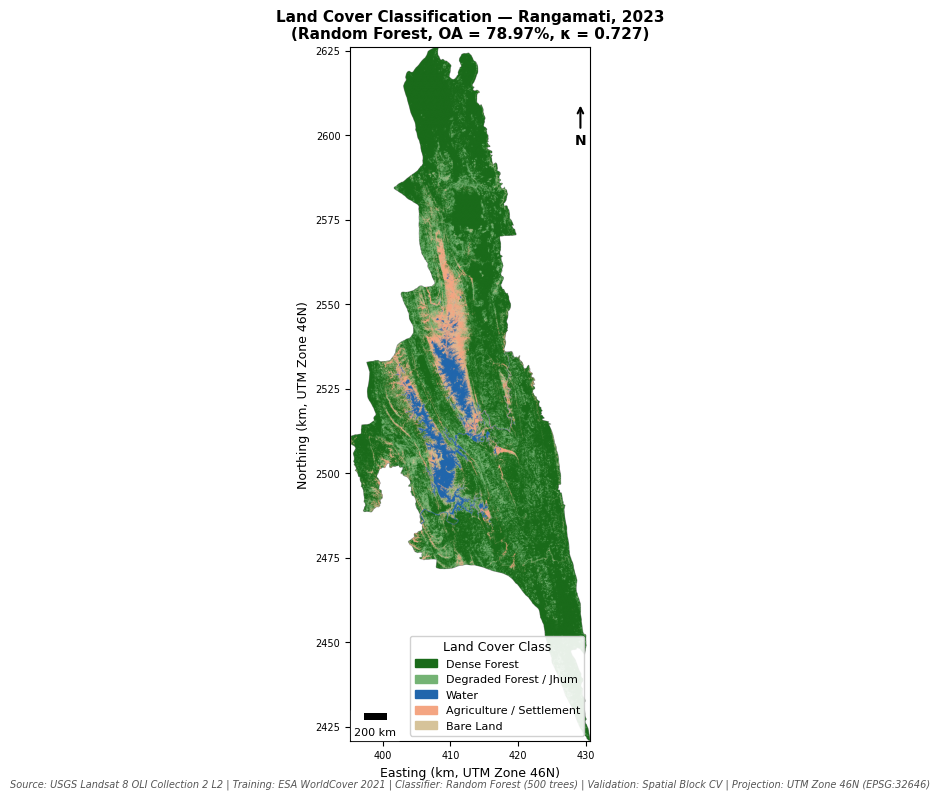

✓ Saved: /content/drive/MyDrive/Rangamati_Deforestation/Maps/Figure2_Classification_2023.png


In [8]:
#  — FIGURE 2: Land Cover Classification 2023
# ============================================================
cmap, norm = make_colormap()
data_2023, transform_2023, crs_2023, bounds_2023 = read_raster(FILES[2023])

fig, ax = plt.subplots(1, 1, figsize=(9, 8))
fig.patch.set_facecolor('white')

ax.imshow(data_2023, cmap=cmap, norm=norm,
          extent=[bounds_2023.left, bounds_2023.right,
                  bounds_2023.bottom, bounds_2023.top])

xticks = ax.get_xticks()
ax.set_xticklabels([f'{x/1000:.0f}' for x in xticks], fontsize=7)
ax.set_xlabel('Easting (km, UTM Zone 46N)', fontsize=9)
yticks = ax.get_yticks()
ax.set_yticklabels([f'{y/1000:.0f}' for y in yticks], fontsize=7)
ax.set_ylabel('Northing (km, UTM Zone 46N)', fontsize=9)

ax.legend(handles=make_legend_patches(), loc='lower right', fontsize=8,
          title='Land Cover Class', title_fontsize=9,
          framealpha=0.9, edgecolor='#cccccc')

add_scale_bar(ax, pixel_size_m=30)
add_north_arrow(ax, x=0.96, y=0.92)
add_map_frame(ax,
    'Land Cover Classification — Rangamati, 2023\n'
    '(Random Forest, OA = 78.97%, κ = 0.727)', fontsize=11)

add_source_text(fig,
    'Source: USGS Landsat 8 OLI Collection 2 L2 | Training: ESA WorldCover 2021 | '
    'Classifier: Random Forest (500 trees) | Validation: Spatial Block CV | '
    'Projection: UTM Zone 46N (EPSG:32646)')

plt.tight_layout()
out_path = f'{DRIVE_OUTPUT}/Figure2_Classification_2023.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Saved: {out_path}")

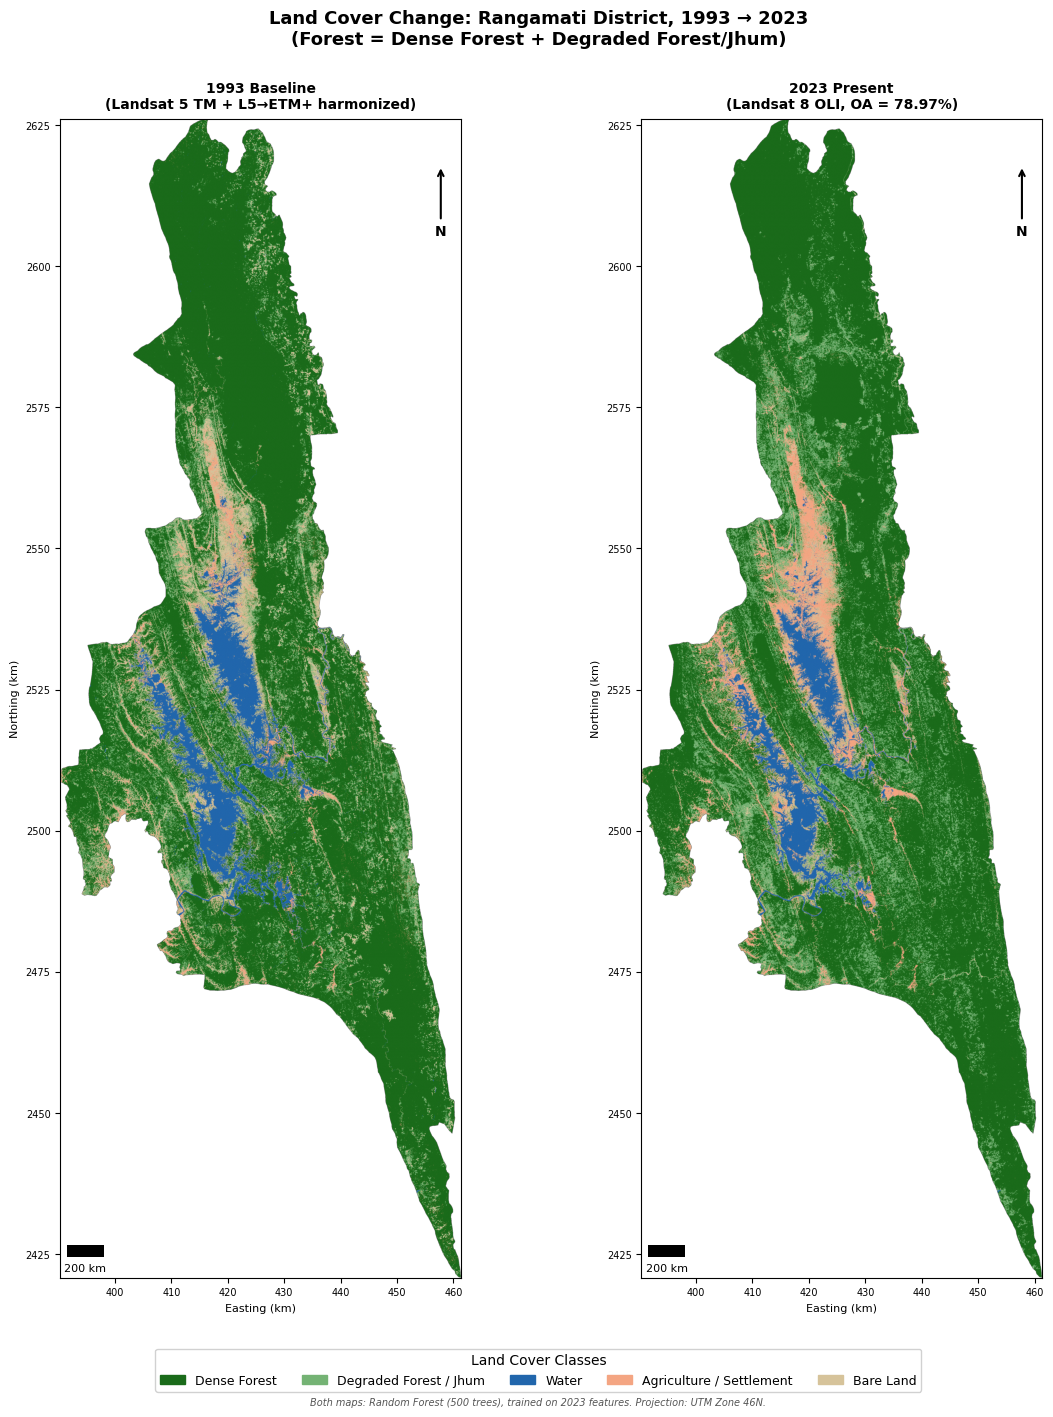

✓ Saved: /content/drive/MyDrive/Rangamati_Deforestation/Maps/Figure3_Comparison_1993_2023.png


In [13]:
# ============================================================
#  FIGURE 3: Land Cover Comparison 1993 vs 2023
# ============================================================
cmap, norm = make_colormap()
data_1993, _, _, bounds_1993 = read_raster(FILES[1993])
data_2023, _, _, bounds_2023 = read_raster(FILES[2023])

fig, axes = plt.subplots(1, 2, figsize=(12, 14))
fig.patch.set_facecolor('white')

titles = {
    1993: '1993 Baseline\n(Landsat 5 TM + L5→ETM+ harmonized)',
    2023: '2023 Present\n(Landsat 8 OLI, OA = 78.97%)',
}
datasets = [(1993, data_1993, bounds_1993), (2023, data_2023, bounds_2023)]

for ax, (yr, data, bounds) in zip(axes, datasets):
    ax.imshow(data, cmap=cmap, norm=norm,
              extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])
    ax.set_aspect('equal')          # ← geographic proportions preserved
    ax.set_title(titles[yr], fontsize=10, fontweight='bold', pad=8)
    ax.set_xlabel('Easting (km)', fontsize=8)
    ax.set_ylabel('Northing (km)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y/1000:.0f}'))
    add_scale_bar(ax, pixel_size_m=30)
    add_north_arrow(ax, x=0.95, y=0.96)

# Shared legend below maps
fig.legend(
    handles=make_legend_patches(),
    loc='lower center', ncol=5, fontsize=9,
    title='Land Cover Classes', title_fontsize=10,
    framealpha=0.9, edgecolor='#cccccc',
    bbox_to_anchor=(0.5, 0.01))

fig.suptitle('Land Cover Change: Rangamati District, 1993 → 2023\n'
             '(Forest = Dense Forest + Degraded Forest/Jhum)',
             fontsize=13, fontweight='bold', y=1.002)

plt.tight_layout(rect=[0, 0.06, 1, 1])

fig.text(0.5, 0.005,
         'Both maps: Random Forest (500 trees), trained on 2023 features. '
         'Projection: UTM Zone 46N.',
         ha='center', fontsize=7, color='#555555', style='italic')

out_path = f'{DRIVE_OUTPUT}/Figure3_Comparison_1993_2023.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Saved: {out_path}")

Stable Forest : 4555.3 km²
Forest Lost   : 132.7 km²
Forest Gained : 326.0 km²
Net change    : +193.3 km²


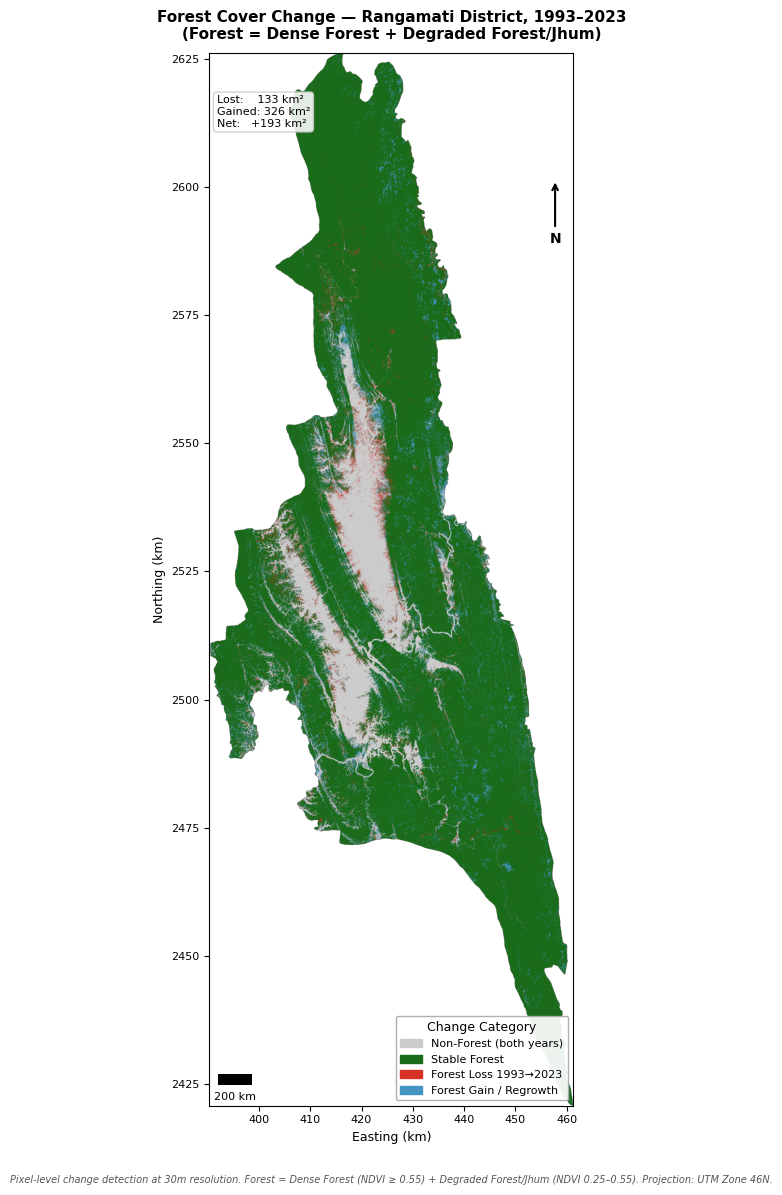

✓ Saved: /content/drive/MyDrive/Rangamati_Deforestation/Maps/Figure4_ForestChange_Map.png


In [14]:
# ============================================================
#  Forest Cover Change Map
# ============================================================
data_1993, _, _, bounds = read_raster(FILES[1993])
data_2023, _, _, _      = read_raster(FILES[2023])

forest_1993 = np.isin(data_1993, [1, 2]).astype(float)
forest_2023 = np.isin(data_2023, [1, 2]).astype(float)
forest_1993[np.isnan(data_1993)] = np.nan
forest_2023[np.isnan(data_2023)] = np.nan

change = np.full_like(data_1993, np.nan)
change[(forest_1993 == 0) & (forest_2023 == 0)] = 0
change[(forest_1993 == 1) & (forest_2023 == 1)] = 1
change[(forest_1993 == 1) & (forest_2023 == 0)] = 2
change[(forest_1993 == 0) & (forest_2023 == 1)] = 3

change_cmap = mcolors.ListedColormap(['#cccccc', '#1a6b1a', '#d73027', '#4393c3'])
change_norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], 4)

px_km2     = (30 * 30) / 1e6
lost_km2   = np.nansum(change == 2) * px_km2
gained_km2 = np.nansum(change == 3) * px_km2
stable_km2 = np.nansum(change == 1) * px_km2
print(f"Stable Forest : {stable_km2:.1f} km²")
print(f"Forest Lost   : {lost_km2:.1f} km²")
print(f"Forest Gained : {gained_km2:.1f} km²")
print(f"Net change    : {gained_km2 - lost_km2:+.1f} km²")

fig, ax = plt.subplots(figsize=(8, 12))
fig.patch.set_facecolor('white')

ax.imshow(change, cmap=change_cmap, norm=change_norm,
          extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])
ax.set_aspect('equal')              # ← correct geographic shape

ax.set_title('Forest Cover Change — Rangamati District, 1993–2023\n'
             '(Forest = Dense Forest + Degraded Forest/Jhum)',
             fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('Easting (km)', fontsize=9)
ax.set_ylabel('Northing (km)', fontsize=9)
ax.tick_params(labelsize=8)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y/1000:.0f}'))

# Legend — lower right
change_patches = [
    mpatches.Patch(color='#cccccc', label='Non-Forest (both years)'),
    mpatches.Patch(color='#1a6b1a', label='Stable Forest'),
    mpatches.Patch(color='#d73027', label='Forest Loss 1993→2023'),
    mpatches.Patch(color='#4393c3', label='Forest Gain / Regrowth'),
]
ax.legend(handles=change_patches,
          loc='lower right', fontsize=8,
          title='Change Category', title_fontsize=9,
          framealpha=0.92, edgecolor='#aaaaaa')

# Stats box — upper left (away from scalebar and legend)
ax.text(0.02, 0.96,
        f'Lost:    {lost_km2:.0f} km²\n'
        f'Gained: {gained_km2:.0f} km²\n'
        f'Net:   {gained_km2 - lost_km2:+.0f} km²',
        transform=ax.transAxes, fontsize=8,
        va='top', ha='left',
        bbox=dict(boxstyle='round', facecolor='white',
                  alpha=0.88, edgecolor='#cccccc'))

# Scalebar — bottom left
add_scale_bar(ax, pixel_size_m=30)

# North arrow — top right
add_north_arrow(ax, x=0.95, y=0.88)

fig.text(0.5, 0.01,
         'Pixel-level change detection at 30m resolution. '
         'Forest = Dense Forest (NDVI ≥ 0.55) + Degraded Forest/Jhum (NDVI 0.25–0.55). '
         'Projection: UTM Zone 46N.',
         ha='center', fontsize=7, color='#555555', style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 1])
out_path = f'{DRIVE_OUTPUT}/Figure4_ForestChange_Map.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Saved: {out_path}")

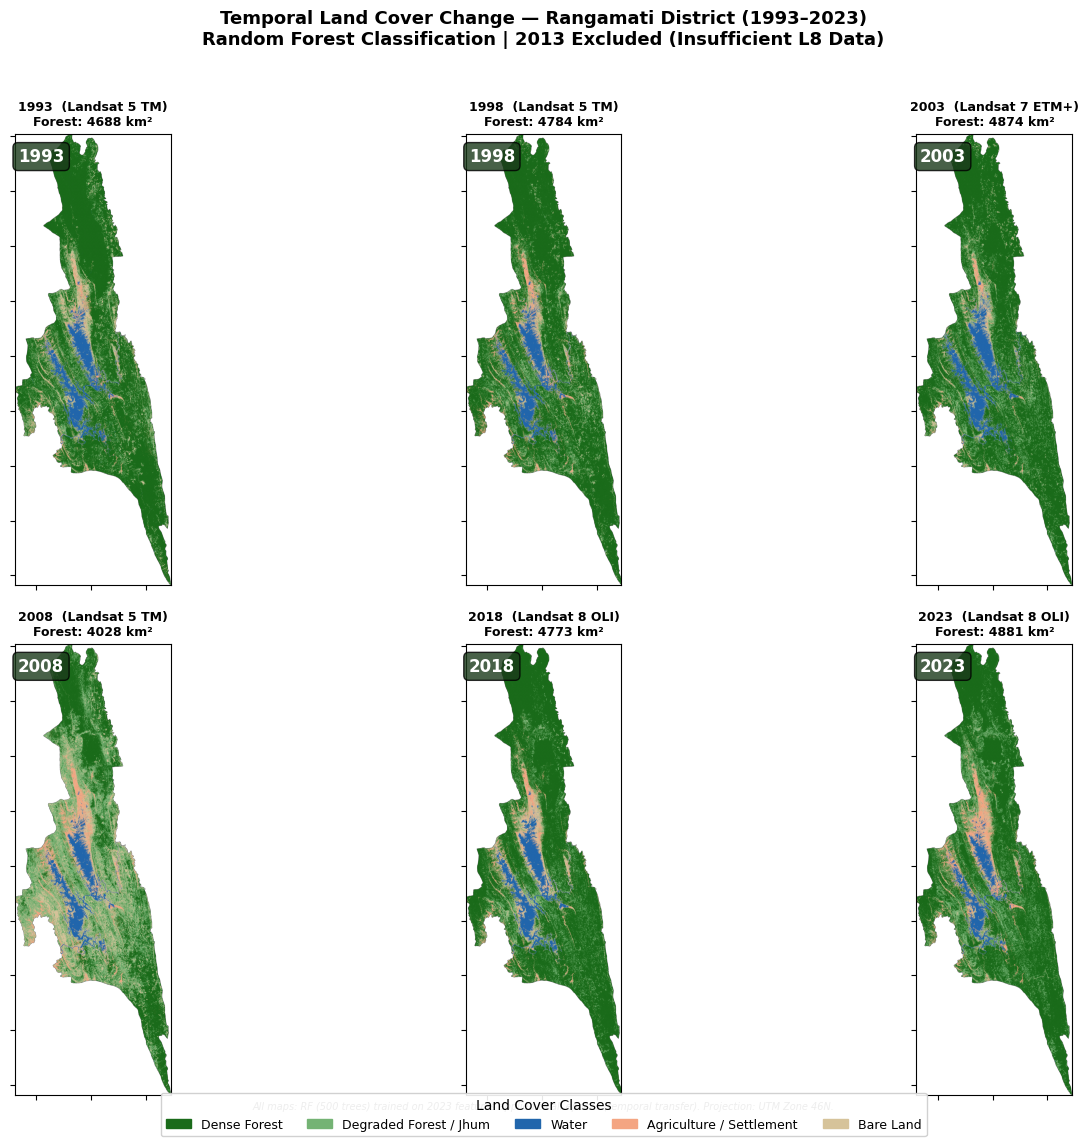

✓ Saved: /content/drive/MyDrive/Rangamati_Deforestation/Maps/Figure5_MultiEpoch_Panel.png


In [15]:

# ============================================================
cmap, norm = make_colormap()
epochs = [1993, 1998, 2003, 2008, 2018, 2023]
sensor_labels = {
    1993: 'Landsat 5 TM', 1998: 'Landsat 5 TM',
    2003: 'Landsat 7 ETM+', 2008: 'Landsat 5 TM',
    2018: 'Landsat 8 OLI',  2023: 'Landsat 8 OLI',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 11))
fig.patch.set_facecolor('white')
axes = axes.flatten()

for i, yr in enumerate(epochs):
    ax = axes[i]
    data, _, _, bounds = read_raster(FILES[yr])
    ax.imshow(data, cmap=cmap, norm=norm,
              extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])

    forest_px  = np.nansum(np.isin(data.astype(int), [1, 2]))
    forest_km2 = forest_px * px_km2

    ax.set_title(f'{yr}  ({sensor_labels[yr]})\nForest: {forest_km2:.0f} km²',
                 fontsize=9, fontweight='bold')
    ax.tick_params(labelbottom=False, labelleft=False)
    ax.text(0.02, 0.97, str(yr), transform=ax.transAxes,
            fontsize=12, fontweight='bold', color='white', va='top',
            bbox=dict(boxstyle='round', facecolor='#1a3a1a', alpha=0.8))

fig.legend(handles=make_legend_patches(),
           loc='lower center', ncol=5, fontsize=9,
           title='Land Cover Classes', title_fontsize=10,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Temporal Land Cover Change — Rangamati District (1993–2023)\n'
             'Random Forest Classification | 2013 Excluded (Insufficient L8 Data)',
             fontsize=13, fontweight='bold', y=1.01)

add_source_text(fig,
    'All maps: RF (500 trees) trained on 2023 features applied to all epochs (temporal transfer). '
    'Projection: UTM Zone 46N.')

plt.tight_layout(pad=1.5)
out_path = f'{DRIVE_OUTPUT}/Figure5_MultiEpoch_Panel.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Saved: {out_path}")

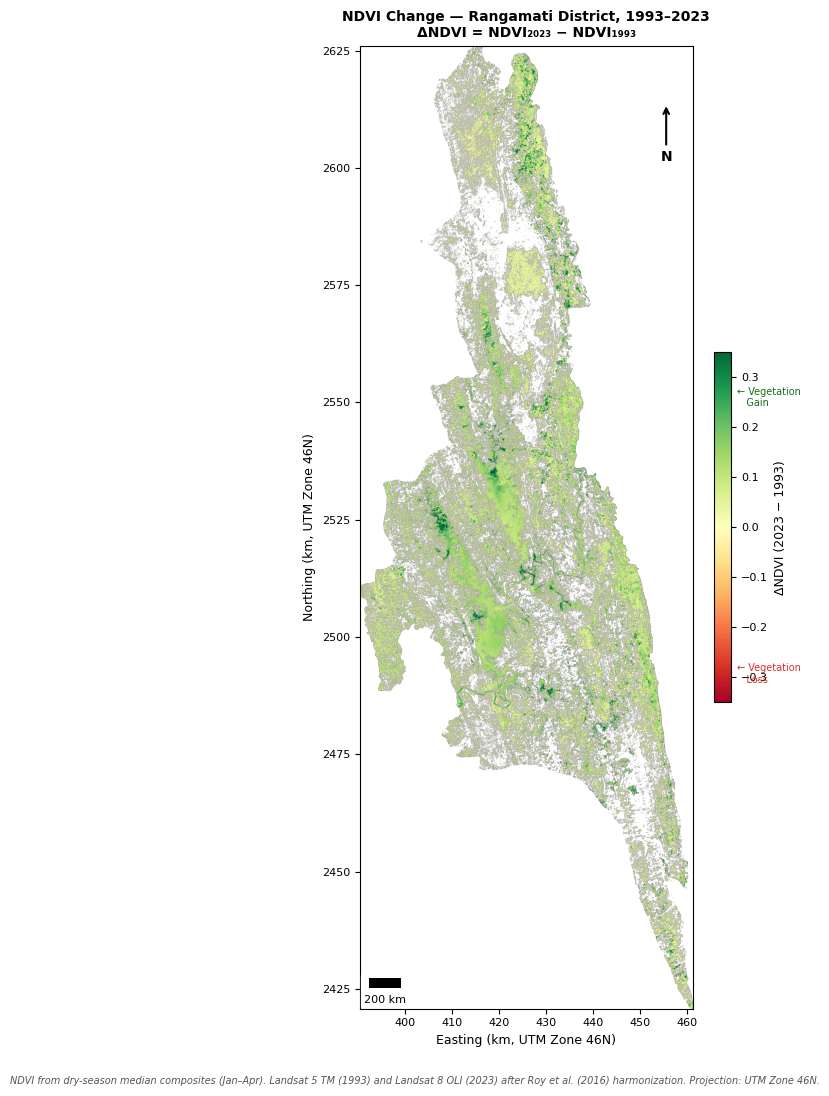

✓ Saved: /content/drive/MyDrive/Rangamati_Deforestation/Maps/Figure6_NDVI_Change.png


In [20]:
# ============================================================
# CELL 10 — FIGURE 6: NDVI Change Map
# ============================================================
data_ndvi, _, _, bounds = read_raster(NDVI_CHANGE)

fig, ax = plt.subplots(figsize=(8, 11))
fig.patch.set_facecolor('white')

vmax = 0.35
img = ax.imshow(data_ndvi, cmap=plt.cm.RdYlGn, vmin=-vmax, vmax=vmax,
                extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])
ax.set_aspect('equal')    # ← correct geographic shape

# Fix tick labels to km (removes 1e6 notation)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y/1000:.0f}'))

ax.set_xlabel('Easting (km, UTM Zone 46N)', fontsize=9)
ax.set_ylabel('Northing (km, UTM Zone 46N)', fontsize=9)
ax.tick_params(labelsize=8)

cbar = plt.colorbar(img, ax=ax, orientation='vertical',
                    fraction=0.025, pad=0.03, shrink=0.75)
cbar.set_label('ΔNDVI (2023 − 1993)', fontsize=9)
cbar.ax.tick_params(labelsize=8)
cbar.set_ticks([-0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3])
cbar.ax.text(1.3, 0.05, '← Vegetation\n   Loss',
             transform=cbar.ax.transAxes, fontsize=7,
             color='#d73027', va='bottom')
cbar.ax.text(1.3, 0.90, '← Vegetation\n   Gain',
             transform=cbar.ax.transAxes, fontsize=7,
             color='#1a6b1a', va='top')

add_scale_bar(ax, pixel_size_m=30)
add_north_arrow(ax, x=0.92, y=0.94)
add_map_frame(ax,
    'NDVI Change — Rangamati District, 1993–2023\n'
    'ΔNDVI = NDVI₂₀₂₃ − NDVI₁₉₉₃', fontsize=10)

fig.text(0.5, 0.01,
         'NDVI from dry-season median composites (Jan–Apr). '
         'Landsat 5 TM (1993) and Landsat 8 OLI (2023) '
         'after Roy et al. (2016) harmonization. Projection: UTM Zone 46N.',
         ha='center', fontsize=7, color='#555555', style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 1])
out_path = f'{DRIVE_OUTPUT}/Figure6_NDVI_Change.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Saved: {out_path}")

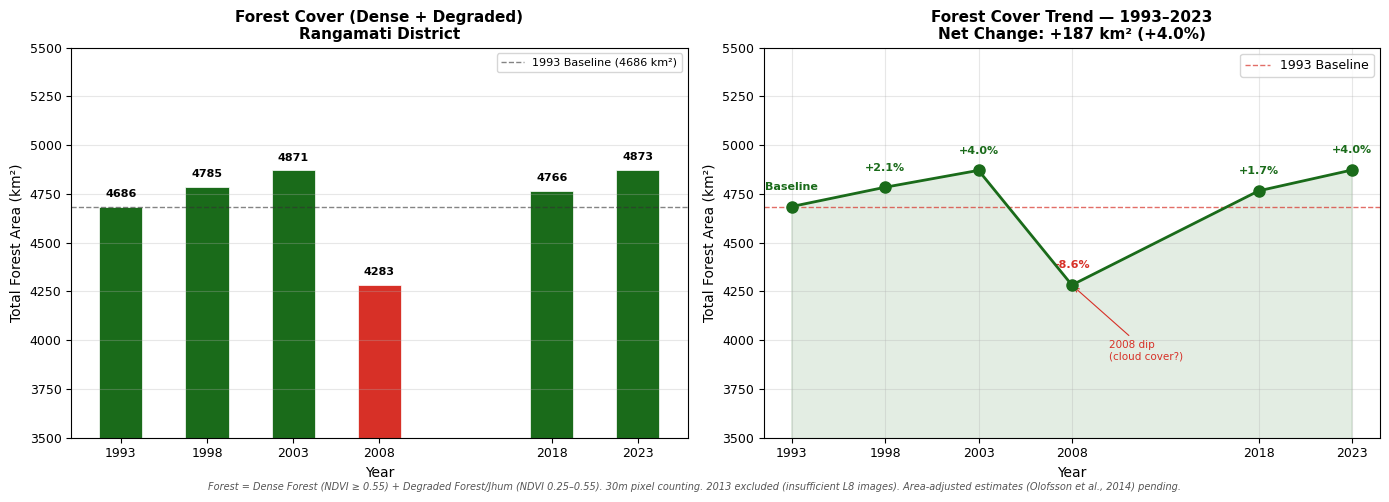

✓ Saved: /content/drive/MyDrive/Rangamati_Deforestation/Maps/Figure7_ForestArea_Chart.png

Net change 1993→2023: +187.3 km² (+4.0%)
Lowest year: 2008 — 4283 km² (-8.6% from baseline)

ALL 7 FIGURES COMPLETE
Saved to: /content/drive/MyDrive/Rangamati_Deforestation/Maps
  1. Figure1_StudyArea.png
  2. Figure2_Classification_2023.png
  3. Figure3_Comparison_1993_2023.png
  4. Figure4_ForestChange_Map.png
  5. Figure5_MultiEpoch_Panel.png
  6. Figure6_NDVI_Change.png
  7. Figure7_ForestArea_Chart.png


In [17]:

# Actual values from GEE (2013 excluded — unreliable L8 composite)
years        = [1993, 1998, 2003, 2008, 2018, 2023]
total_forest = [4685.7, 4784.6, 4871.1, 4283.0, 4766.0, 4873.0]
baseline     = total_forest[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

# ---- Left: Bar chart ----
ax1 = axes[0]
bar_colors = ['#d73027' if v < baseline else '#1a6b1a' for v in total_forest]
bars = ax1.bar(years, total_forest, width=2.5,
               color=bar_colors, edgecolor='white', linewidth=0.5)
ax1.axhline(baseline, color='#333333', linestyle='--', linewidth=1,
            alpha=0.6, label=f'1993 Baseline ({baseline:.0f} km²)')
ax1.set_xlabel('Year', fontsize=10)
ax1.set_ylabel('Total Forest Area (km²)', fontsize=10)
ax1.set_title('Forest Cover (Dense + Degraded)\nRangamati District',
              fontsize=11, fontweight='bold')
ax1.set_xticks(years)
ax1.set_ylim(3500, 5500)
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(labelsize=9)
for bar, val in zip(bars, total_forest):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 50,
             f'{val:.0f}', ha='center', fontsize=8, fontweight='bold')

# ---- Right: Trend line ----
ax2 = axes[1]
ax2.plot(years, total_forest, 'o-', color='#1a6b1a',
         linewidth=2, markersize=8, zorder=5)
ax2.fill_between(years, total_forest, alpha=0.12, color='#1a6b1a')
ax2.axhline(baseline, color='#d73027', linestyle='--',
            linewidth=1, alpha=0.7, label='1993 Baseline')

for yr, val in zip(years, total_forest):
    pct   = (val - baseline) / baseline * 100
    label = 'Baseline' if yr == 1993 else f'{pct:+.1f}%'
    color = '#d73027' if pct < 0 else '#1a6b1a'
    ax2.annotate(label, xy=(yr, val),
                 xytext=(0, 12), textcoords='offset points',
                 ha='center', fontsize=8, color=color, fontweight='bold')

# Flag 2008 anomaly
ax2.annotate('2008 dip\n(cloud cover?)',
             xy=(2008, 4283), xytext=(2010, 3900),
             fontsize=7.5, color='#d73027',
             arrowprops=dict(arrowstyle='->', color='#d73027', lw=0.8))

ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylabel('Total Forest Area (km²)', fontsize=10)
ax2.set_title('Forest Cover Trend — 1993–2023\n'
              f'Net Change: +{total_forest[-1]-baseline:.0f} km² '
              f'({(total_forest[-1]-baseline)/baseline*100:+.1f}%)',
              fontsize=11, fontweight='bold')
ax2.set_xticks(years)
ax2.legend(fontsize=9)
ax2.set_ylim(3500, 5500)
ax2.grid(alpha=0.3)
ax2.tick_params(labelsize=9)

add_source_text(fig,
    'Forest = Dense Forest (NDVI ≥ 0.55) + Degraded Forest/Jhum (NDVI 0.25–0.55). '
    '30m pixel counting. 2013 excluded (insufficient L8 images). '
    'Area-adjusted estimates (Olofsson et al., 2014) pending.')

plt.tight_layout()
out_path = f'{DRIVE_OUTPUT}/Figure7_ForestArea_Chart.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✓ Saved: {out_path}")
print(f"\nNet change 1993→2023: {total_forest[-1]-baseline:+.1f} km² "
      f"({(total_forest[-1]-baseline)/baseline*100:+.1f}%)")
print(f"Lowest year: 2008 — {total_forest[3]:.0f} km² "
      f"({(total_forest[3]-baseline)/baseline*100:.1f}% from baseline)")

print("\n" + "="*50)
print("ALL 7 FIGURES COMPLETE")
print(f"Saved to: {DRIVE_OUTPUT}")
print("="*50)
for i in range(1, 8):
    fname = [
        'Figure1_StudyArea.png',
        'Figure2_Classification_2023.png',
        'Figure3_Comparison_1993_2023.png',
        'Figure4_ForestChange_Map.png',
        'Figure5_MultiEpoch_Panel.png',
        'Figure6_NDVI_Change.png',
        'Figure7_ForestArea_Chart.png',
    ][i-1]
    print(f"  {i}. {fname}")